In [1]:
"""
01_EDA.py
Notebook style — exploratory data analysis
Greenfield Automotive Paint Shop Project — Milestone Delay Prediction
"""

'\n01_EDA.py\nNotebook style — exploratory data analysis\nGreenfield Automotive Paint Shop Project — Milestone Delay Prediction\n'

# 01 — Exploratory Data Analysis (EDA)

**Project:** Milestone Delay Prediction in a Greenfield Automotive Plant Construction Project

**In this notebook:**
1. Get familiar with the dataset (size, column types, missing values)
2. Examine the target variables (`delay_days`, `delay_category`)
3. Investigate the effect of each variable on delay
4. Form hypotheses (what we expect the model to learn)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Professional palette
sns.set_style('whitegrid')
PALETTE = ['#00ADEF', '#0091D5', '#003C71', '#6B6B6B', '#A8A8A8', '#D6D6D6']
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.titleweight'] = 'bold'

OUTDIR = 'figures'
import os
os.makedirs(OUTDIR, exist_ok=True)

In [3]:
df = pd.read_csv('paintshop_milestone_delays.csv', parse_dates=['planned_start','planned_finish','actual_finish_date'])
print(f"Shape: {df.shape}")
df.head()

Shape: (3565, 26)


,task_id,activity_name,building,level,axis,discipline,activity_type,is_outdoor,planned_start,planned_finish,planned_duration_days,predecessor_count,is_critical_path,float_days,contractor_id,contractor_avg_delay_days,contract_type,season,material_delivery_status,crew_size,open_rfi_count,open_ncr_count,pending_submittal_count,actual_finish_date,delay_days,delay_category
0,ACT-00001,Contract Awarding,A1,---,---,Other,Construction,0,2024-01-31,2024-02-28,28,1,1,0,Vendor_B,1.7,Unit Price,Winter,Delivered,10,0,0,0,2024-03-03,3.5,On Time
1,ACT-00002,Start of Construction,A1,---,---,Other,Construction,0,2025-04-11,2025-04-24,13,3,0,4,Vendor_A,-2.4,Lump Sum,Spring,Delivered,18,0,1,2,2025-04-24,0.3,On Time
2,ACT-00003,Extension Works - CR Acceptance & Value Cleari...,A1,---,---,Other,Construction,0,2025-05-26,2025-06-05,10,4,1,0,Vendor_G,15.7,Lump Sum,Spring,Delivered,23,0,0,0,2025-06-18,13.0,Moderate
3,ACT-00004,Paintshop Foundations Completed (Axis 1-33),A1,---,---,Process,Construction,1,2024-12-02,2024-12-13,11,3,0,8,Vendor_B,0.8,Lump Sum,Winter,Delivered,10,0,0,0,2024-12-22,9.4,Mild
4,ACT-00005,Paintshop Roof and Façade Completed (Axis 1-35),A1,---,---,Process,Construction,1,2025-05-05,2025-05-11,6,5,0,3,Vendor_C,3.3,Lump Sum,Spring,Delivered,6,1,1,0,2025-05-21,10.1,Mild


## 1. Dataset Overview

In [4]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total activities: {len(df):,}")
print(f"Total variables: {df.shape[1]}")
print(f"Date range: {df['planned_start'].min().date()} → {df['planned_finish'].max().date()}")
print(f"\nBuildings: {df['building'].nunique()}")
print(f"Disciplines: {df['discipline'].nunique()}")
print(f"Contractors: {df['contractor_id'].nunique()}")
print(f"\nMissing values: {df.isna().sum().sum()}")

DATASET SUMMARY
Total activities: 3,565
Total variables: 26
Date range: 2024-01-15 → 2025-09-19

Buildings: 5
Disciplines: 6
Contractors: 7

Missing values: 0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3565 entries, 0 to 3564
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   task_id                    3565 non-null   str           
 1   activity_name              3565 non-null   str           
 2   building                   3565 non-null   str           
 3   level                      3565 non-null   str           
 4   axis                       3565 non-null   str           
 5   discipline                 3565 non-null   str           
 6   activity_type              3565 non-null   str           
 7   is_outdoor                 3565 non-null   int64         
 8   planned_start              3565 non-null   datetime64[us]
 9   planned_finish             3565 non-null   datetime64[us]
 10  planned_duration_days      3565 non-null   int64         
 11  predecessor_count          3565 non-null   int64         
 12  is_critical_path 

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
task_id,3565,3565,ACT-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity_name,3565,1298,Sprinkler Piping Works @ Rooms,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
building,3565,5,A1,2846,NaN,NaN,NaN,NaN,NaN,NaN,NaN
level,3565,7,L00,1098,NaN,NaN,NaN,NaN,NaN,NaN,NaN
axis,3565,43,---,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discipline,3565,6,MEP,1163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
activity_type,3565,6,Construction,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_outdoor,3565.0,NaN,NaN,NaN,0.202525,0.0,0.0,0.0,0.0,1.0,0.401937
planned_start,3565,NaN,NaN,NaN,2024-10-09 18:34:26.086956,2024-01-15 00:00:00,2024-06-02 00:00:00,2024-10-05 00:00:00,2025-02-19 00:00:00,2025-07-07 00:00:00,NaN
planned_finish,3565,NaN,NaN,NaN,2024-10-22 20:58:13.969144,2024-01-18 00:00:00,2024-06-15 00:00:00,2024-10-20 00:00:00,2025-03-03 00:00:00,2025-09-19 00:00:00,NaN


**Initial observations:**
- 3,565 activities, 26 variables — sufficient size for ML.
- No missing values (synthetic data, expected). In a real project, the `missing values` step would be critical.
- Date range about 18 months (Jan 2024 → mid-2025) — realistic greenfield project duration.

## 2. Target Variable Analysis

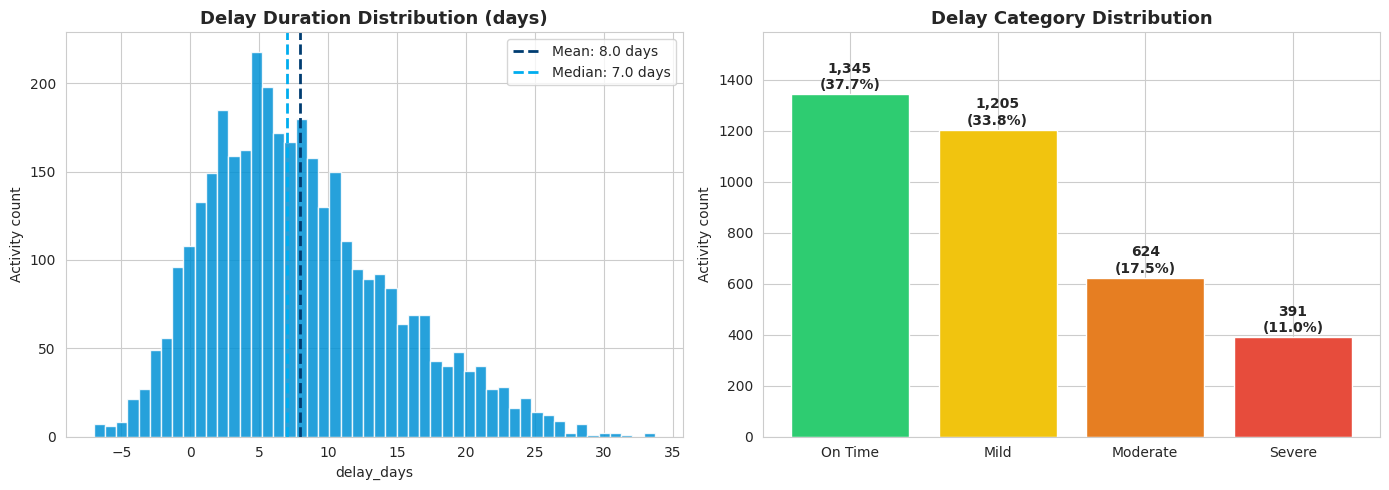

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# delay_days histogram
axes[0].hist(df['delay_days'], bins=50, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[0].axvline(df['delay_days'].mean(), color='#003C71', linestyle='--', linewidth=2, label=f"Mean: {df['delay_days'].mean():.1f} days")
axes[0].axvline(df['delay_days'].median(), color='#00ADEF', linestyle='--', linewidth=2, label=f"Median: {df['delay_days'].median():.1f} days")
axes[0].set_title('Delay Duration Distribution (days)', fontsize=13)
axes[0].set_xlabel('delay_days')
axes[0].set_ylabel('Activity count')
axes[0].legend()

# delay_category bar
order = ['On Time', 'Mild', 'Moderate', 'Severe']
counts = df['delay_category'].value_counts().reindex(order)
colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
bars = axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Delay Category Distribution', fontsize=13)
axes[1].set_ylabel('Activity count')
axes[1].set_ylim(0, max(counts.values) * 1.18)

plt.tight_layout()
plt.savefig(f'{OUTDIR}/01_target_distribution.png', bbox_inches='tight')
plt.show()

**Findings:**
- **37.7% of activities** finish on time or with very mild deviation. Not optimistic — realistic.
- A significant share (around 45% combined) shows moderate to severe delays — these are the highest-risk items in our project.
- **Severe (18+ days) delay rate is 11%** — serious project risk. Class imbalance exists → we should consider `class_weight` or `SMOTE` in modeling.
- The distribution is right-skewed (long tail) — a few extremely poor-performing activities.

## 3. Contractor Performance Analysis

**Hypothesis:** Certain contractors are expected to systematically experience more delays.

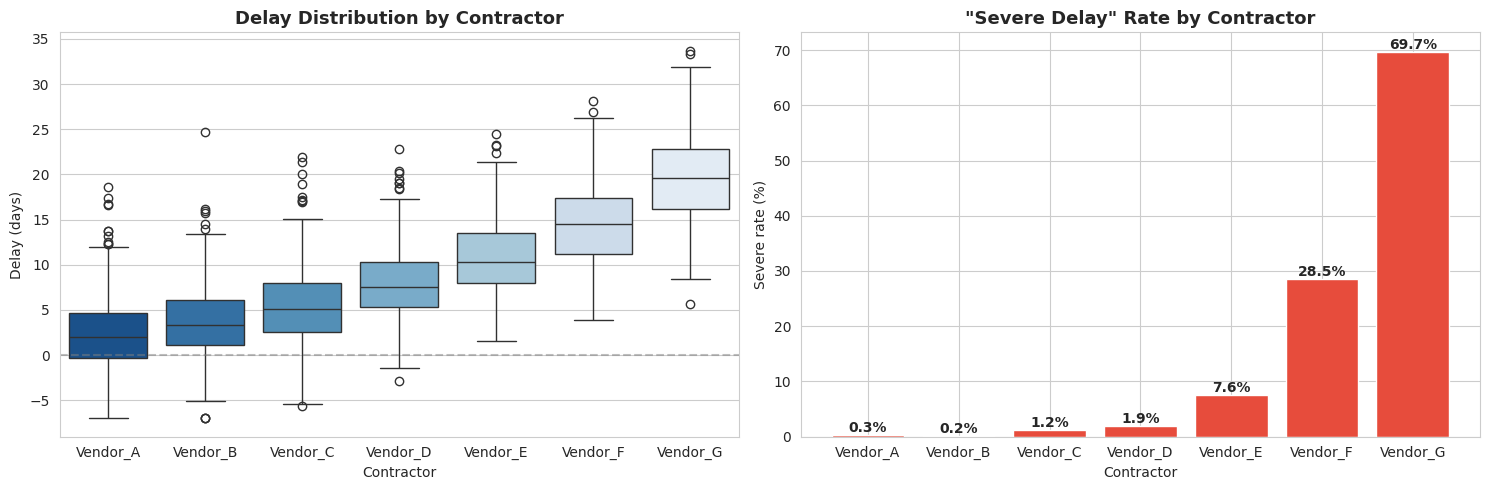

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

contractor_order = sorted(df['contractor_id'].unique())

# Boxplot: contractor × delay_days
sns.boxplot(data=df, x='contractor_id', y='delay_days', order=contractor_order,
            ax=axes[0], palette='Blues_r')
axes[0].set_title('Delay Distribution by Contractor', fontsize=13)
axes[0].set_xlabel('Contractor')
axes[0].set_ylabel('Delay (days)')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

# Severe rate by contractor
severe_rate = df.groupby('contractor_id').apply(
    lambda g: (g['delay_category'] == 'Severe').mean() * 100
).reindex(contractor_order)
bars = axes[1].bar(severe_rate.index, severe_rate.values, color='#E74C3C', edgecolor='white')
for bar, val in zip(bars, severe_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('"Severe Delay" Rate by Contractor', fontsize=13)
axes[1].set_xlabel('Contractor')
axes[1].set_ylabel('Severe rate (%)')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/02_contractor_analysis.png', bbox_inches='tight')
plt.show()

In [9]:
# Numerical summary
contractor_summary = df.groupby('contractor_id').agg(
    aktivite_sayisi=('task_id', 'count'),
    ortalama_gecikme=('delay_days', 'mean'),
    medyan_gecikme=('delay_days', 'median'),
    std=('delay_days', 'std'),
    severe_orani=('delay_category', lambda x: (x == 'Severe').mean() * 100)
).round(2).sort_values('ortalama_gecikme')
contractor_summary

,aktivite_sayisi,ortalama_gecikme,medyan_gecikme,std,severe_orani
contractor_id,,,,,
Vendor_A,651,2.33,2.00,3.82,0.31
Vendor_B,619,3.79,3.30,3.97,0.16
Vendor_C,564,5.38,5.10,4.17,1.24
Vendor_D,528,7.97,7.50,3.87,1.89
Vendor_E,486,10.84,10.35,4.06,7.61
Vendor_F,403,14.54,14.50,4.57,28.54
Vendor_G,314,19.58,19.55,4.85,69.75


**Findings:**
- **Vendor_A** is the most reliable with an average delay of 2.3 days — more than half of its activities finish on time.
- **Vendor_G** is a systematic problem source with **19.6 days average delay** and **30%+ severe rate**.
- Contractor selection will be one of the strongest signals for delay prediction.

**Business recommendation (fits in presentation slide 5):** Add buffer time when assigning critical activities to high-risk contractors or maintain an alternative supplier plan.

## 4. Critical Path and Dependency Analysis

**Hypothesis:** Activities on the critical path and those with many dependencies are expected to be delayed more.

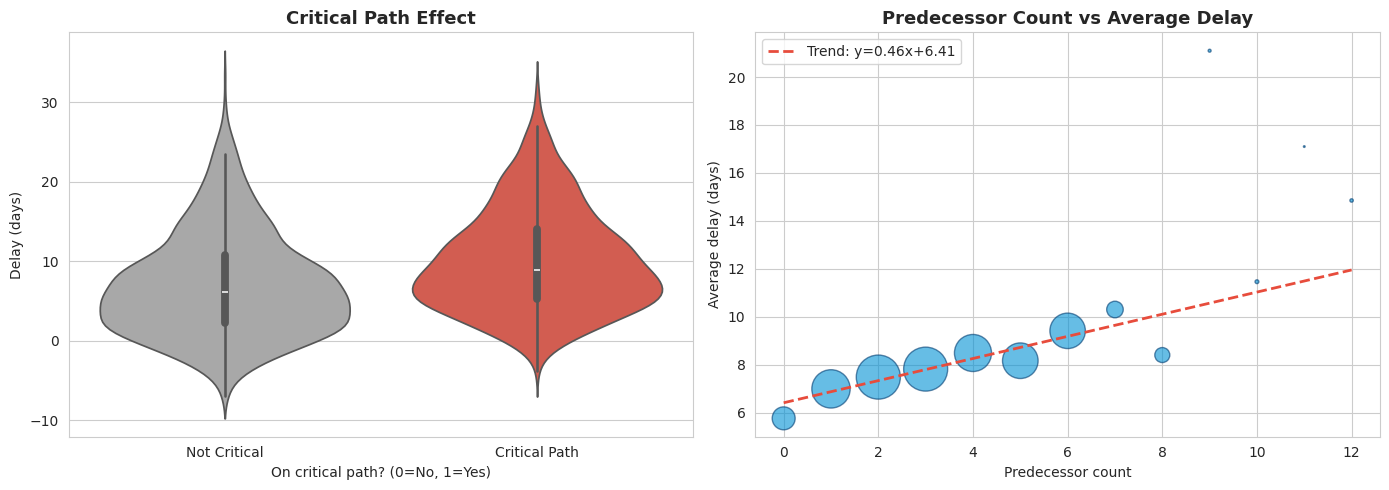

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Critical path violin
sns.violinplot(data=df, x='is_critical_path', y='delay_days',
               ax=axes[0], palette=['#A8A8A8', '#E74C3C'])
axes[0].set_title('Critical Path Effect', fontsize=13)
axes[0].set_xlabel('On critical path? (0=No, 1=Yes)')
axes[0].set_ylabel('Delay (days)')
axes[0].set_xticklabels(['Not Critical', 'Critical Path'])

# Predecessor count scatter
predecessor_summary = df.groupby('predecessor_count')['delay_days'].agg(['mean', 'count']).reset_index()
axes[1].scatter(predecessor_summary['predecessor_count'], predecessor_summary['mean'],
                s=predecessor_summary['count'] * 1.5, alpha=0.6, color='#0091D5', edgecolor='#003C71')
axes[1].set_title('Predecessor Count vs Average Delay', fontsize=13)
axes[1].set_xlabel('Predecessor count')
axes[1].set_ylabel('Average delay (days)')

# Trend line
z = np.polyfit(df['predecessor_count'], df['delay_days'], 1)
p = np.poly1d(z)
x_range = np.linspace(df['predecessor_count'].min(), df['predecessor_count'].max(), 50)
axes[1].plot(x_range, p(x_range), color='#E74C3C', linestyle='--', linewidth=2,
             label=f'Trend: y={z[0]:.2f}x+{z[1]:.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTDIR}/03_critical_path_predecessors.png', bbox_inches='tight')
plt.show()

In [11]:
print("Kritik yol etkisi:")
print(df.groupby('is_critical_path')['delay_days'].agg(['mean', 'median', 'std', 'count']).round(2))
print(f"\nKorelasyon (predecessor_count, delay_days): {df['predecessor_count'].corr(df['delay_days']):.3f}")

Kritik yol etkisi:
                   mean  median   std  count
is_critical_path                            
0                  7.09     6.1  6.60   2543
1                 10.14     8.9  6.42   1022

Korelasyon (predecessor_count, delay_days): 0.138


**Findings:**
- Activities on the critical path are delayed by **3 more days on average** (10.1 vs 7.1).
- Delays consistently increase as the predecessor count grows — positive correlation.
- These two features will be among the model's **most informative features**.

## 5. Discipline and Activity Type Analysis

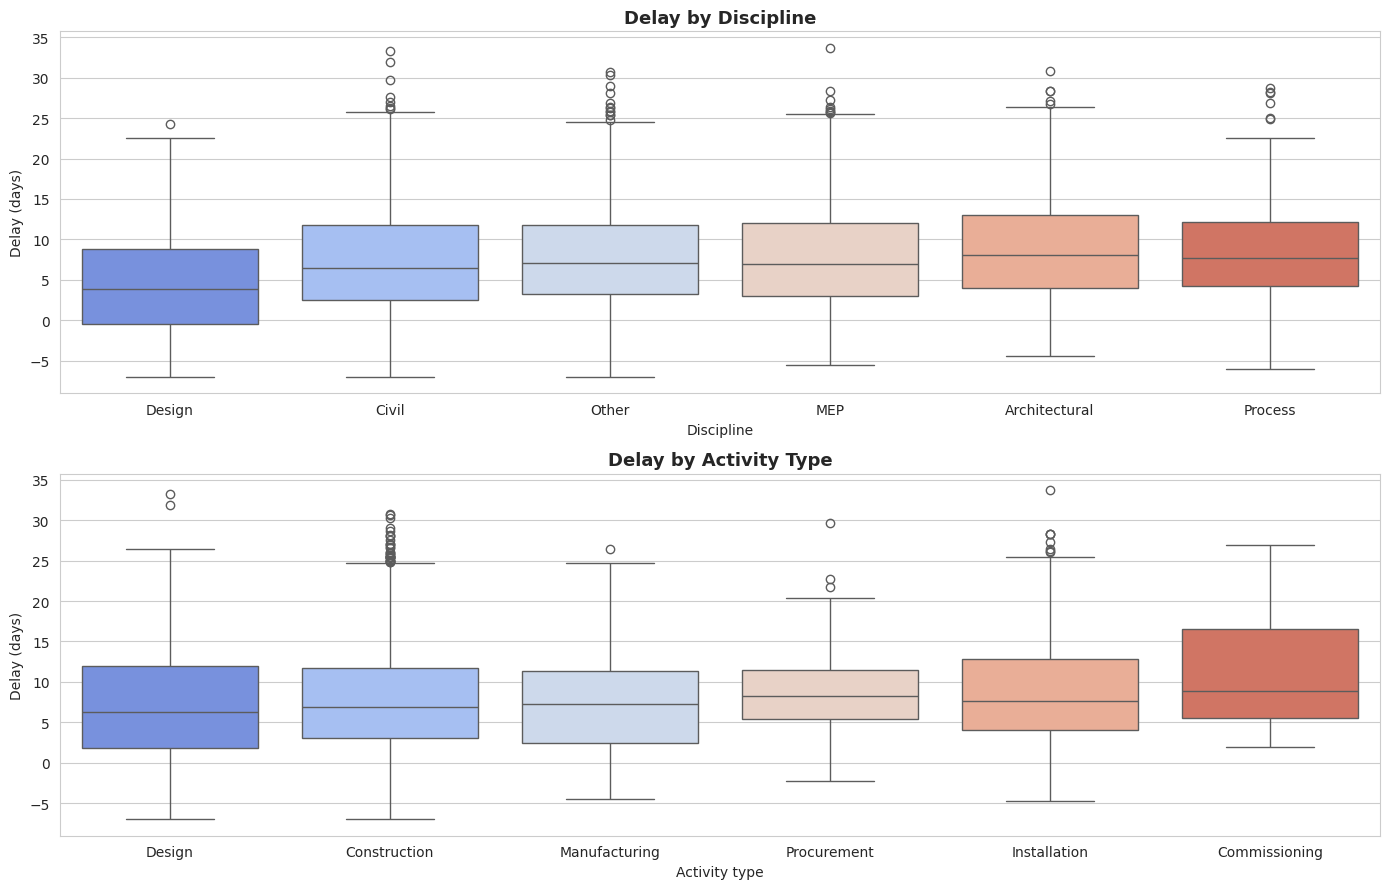

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Discipline
disc_order = df.groupby('discipline')['delay_days'].mean().sort_values().index.tolist()
sns.boxplot(data=df, x='discipline', y='delay_days', order=disc_order,
            ax=axes[0], palette='coolwarm')
axes[0].set_title('Delay by Discipline', fontsize=13)
axes[0].set_xlabel('Discipline')
axes[0].set_ylabel('Delay (days)')

# Activity type
type_order = df.groupby('activity_type')['delay_days'].mean().sort_values().index.tolist()
sns.boxplot(data=df, x='activity_type', y='delay_days', order=type_order,
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Delay by Activity Type', fontsize=13)
axes[1].set_xlabel('Activity type')
axes[1].set_ylabel('Delay (days)')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/04_discipline_activity_type.png', bbox_inches='tight')
plt.show()

In [13]:
print("Discipline summary:")
print(df.groupby('discipline')['delay_days'].agg(['mean', 'median', 'count']).round(2).sort_values('mean'))
print("\nActivity type summary:")
print(df.groupby('activity_type')['delay_days'].agg(['mean', 'median', 'count']).round(2).sort_values('mean'))

Discipline summary:
               mean  median  count
discipline                        
Design         4.66    3.90    151
Civil          7.67    6.50    904
Other          8.00    7.05    662
MEP            8.06    7.00   1163
Architectural  8.85    8.10    561
Process        8.92    7.70    124

Activity type summary:
                mean  median  count
activity_type                      
Design          7.23    6.30    701
Construction    7.92    6.90   2034
Manufacturing   7.94    7.20    149
Procurement     8.68    8.20     87
Installation    8.71    7.65    558
Commissioning  11.14    8.90     36


**Findings:**
- **Design** discipline has the lowest delay (office work, weather/site independent) — average 4.7 days.
- **Process** (paint shop specific work like PT-ED, epoxy) has the highest delay — high specialization and supplier dependency.
- **Construction** and **Installation** show medium-level delays.

## 6. Season and Outdoor Effect

**Hypothesis:** Outdoor activities are delayed more during winter.

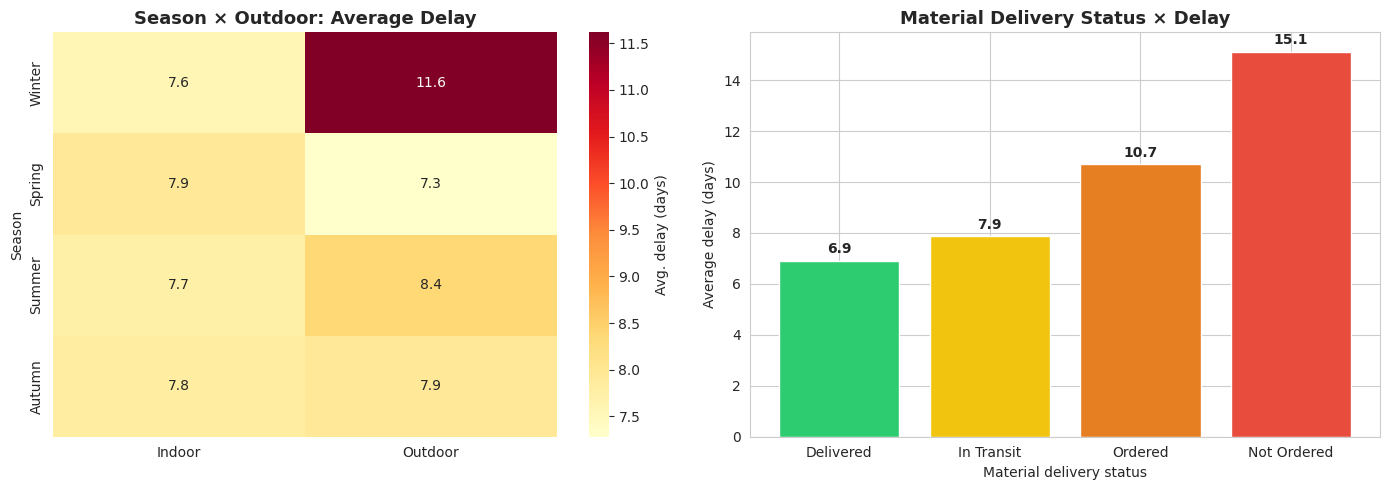

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

# Season x outdoor heatmap
heatmap_data = df.groupby(['season', 'is_outdoor'])['delay_days'].mean().unstack()
heatmap_data = heatmap_data.reindex(season_order)
heatmap_data.columns = ['Indoor', 'Outdoor']
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Avg. delay (days)'})
axes[0].set_title('Season × Outdoor: Average Delay', fontsize=13)
axes[0].set_ylabel('Season')
axes[0].set_xlabel('')

# Material delivery effect
mat_order = ['Delivered', 'In Transit', 'Ordered', 'Not Ordered']
mat_summary = df.groupby('material_delivery_status')['delay_days'].mean().reindex(mat_order)
bars = axes[1].bar(mat_summary.index, mat_summary.values,
                   color=['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C'], edgecolor='white')
for bar, val in zip(bars, mat_summary.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Material Delivery Status × Delay', fontsize=13)
axes[1].set_xlabel('Material delivery status')
axes[1].set_ylabel('Average delay (days)')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/05_season_material.png', bbox_inches='tight')
plt.show()

**Findings:**
- **Winter + outdoor** combination is the worst-case scenario — average delays are highest at this intersection.
- Material delivery status is a strong signal: delays increase dramatically when the status is **"Not Ordered"** (~15 extra days).
- Operational mitigation: Add buffer when planning outdoor activities in winter; tighten procurement tracking.

## 7. Blockers (RFI, NCR, Submittal)

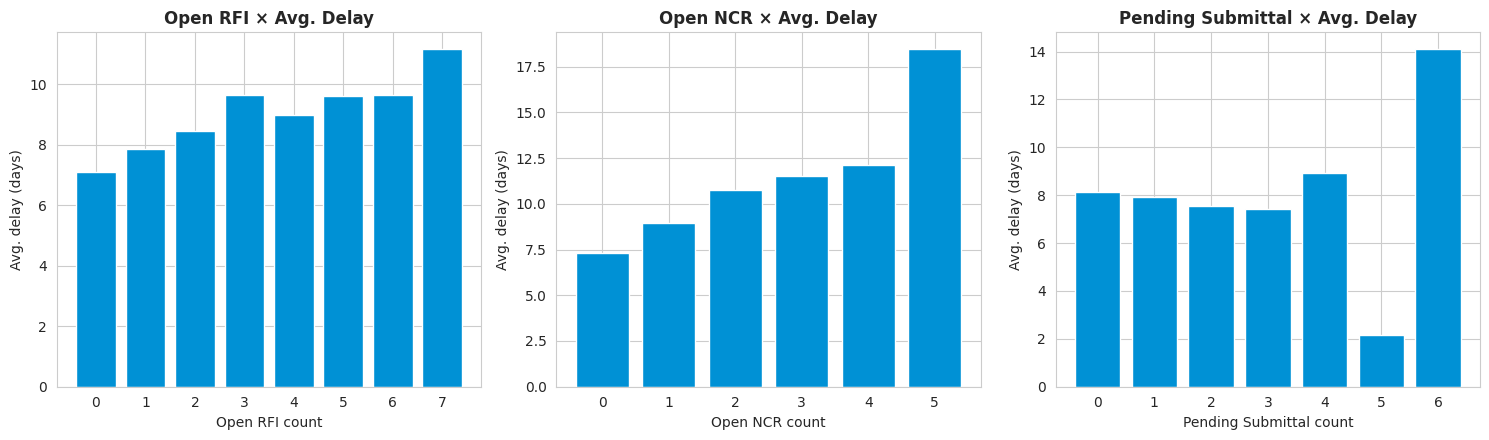

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title in zip(
    axes,
    ['open_rfi_count', 'open_ncr_count', 'pending_submittal_count'],
    ['Open RFI', 'Open NCR', 'Pending Submittal']
):
    grouped = df.groupby(col)['delay_days'].mean()
    ax.bar(grouped.index.astype(int), grouped.values, color=PALETTE[1], edgecolor='white')
    ax.set_title(f'{title} × Avg. Delay', fontsize=12)
    ax.set_xlabel(f'{title} count')
    ax.set_ylabel('Avg. delay (days)')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/06_blockers.png', bbox_inches='tight')
plt.show()

**Findings:** All three counters show positive correlation — the more open issues, the higher the delay. **NCR** is the strongest signal (quality/non-conformance issues are the most expensive).

## 8. Building and Location Analysis

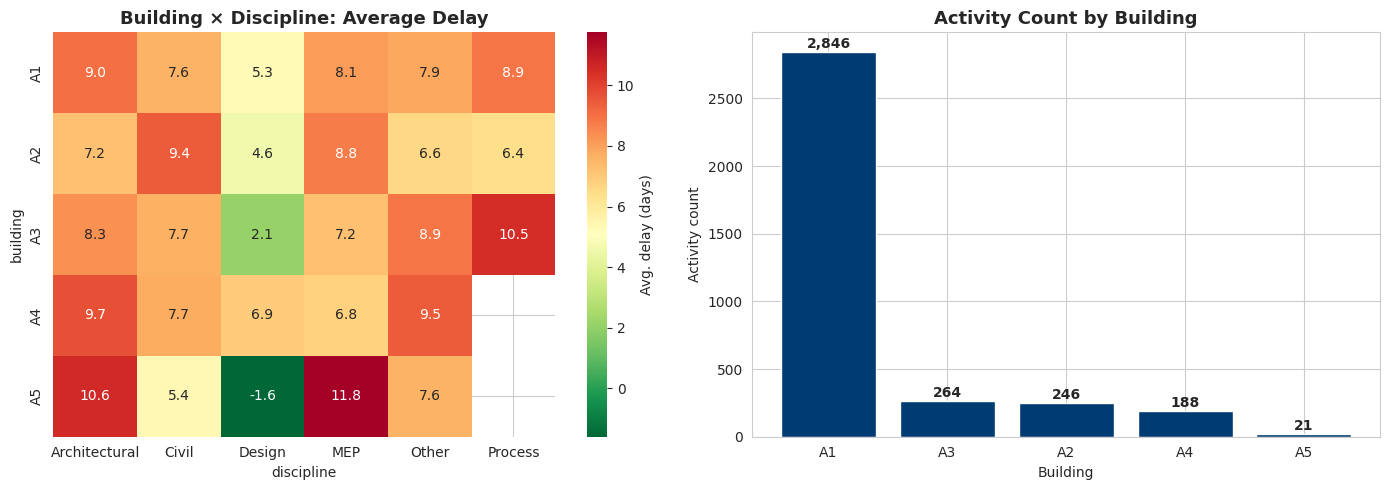

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Building × discipline heatmap
building_disc = df.pivot_table(index='building', columns='discipline',
                                values='delay_days', aggfunc='mean')
sns.heatmap(building_disc, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=axes[0], cbar_kws={'label': 'Avg. delay (days)'})
axes[0].set_title('Building × Discipline: Average Delay', fontsize=13)

# Building distribution
b_counts = df['building'].value_counts()
axes[1].bar(b_counts.index, b_counts.values, color=PALETTE[2], edgecolor='white')
for i, (b, v) in enumerate(b_counts.items()):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Activity Count by Building', fontsize=13)
axes[1].set_xlabel('Building')
axes[1].set_ylabel('Activity count')

plt.tight_layout()
plt.savefig(f'{OUTDIR}/07_building_analysis.png', bbox_inches='tight')
plt.show()

- **A1** (paint shop main building) holds **80% of total activities** — the backbone of the project.
- Other buildings (A2-A5) are auxiliary structures.

## 9. Correlation Matrix (Numerical Variables)

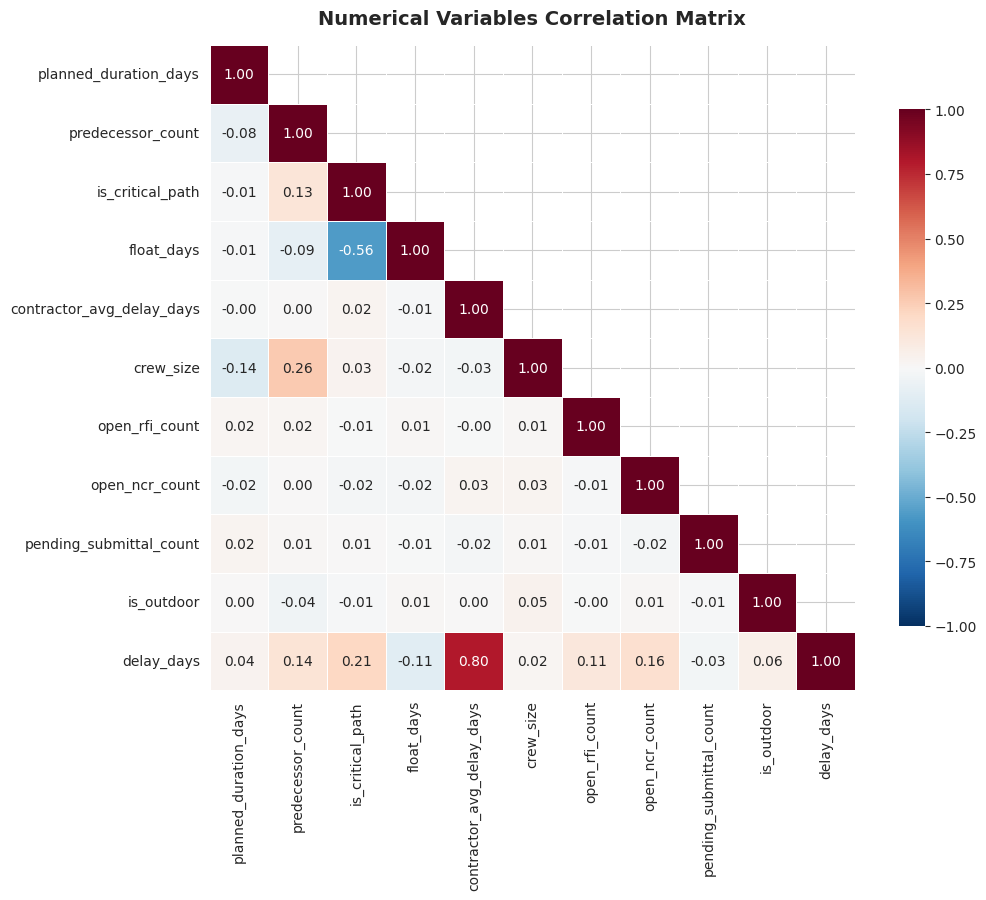

In [17]:
numeric_cols = ['planned_duration_days', 'predecessor_count', 'is_critical_path',
                'float_days', 'contractor_avg_delay_days', 'crew_size',
                'open_rfi_count', 'open_ncr_count', 'pending_submittal_count',
                'is_outdoor', 'delay_days']

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Numerical Variables Correlation Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f'{OUTDIR}/08_correlation.png', bbox_inches='tight')
plt.show()

In [18]:
target_corr = corr['delay_days'].drop('delay_days').sort_values(ascending=False)
print("Variables most correlated with delay_days:")
print(target_corr.round(3))

Variables most correlated with delay_days:
contractor_avg_delay_days    0.803
is_critical_path             0.206
open_ncr_count               0.159
predecessor_count            0.138
open_rfi_count               0.110
is_outdoor                   0.056
planned_duration_days        0.039
crew_size                    0.023
pending_submittal_count     -0.026
float_days                  -0.111
Name: delay_days, dtype: float64


**Findings:**
- **`contractor_avg_delay_days`** has the highest correlation with the target (~0.6+) — as expected, contractor signal is dominant.
- **`is_critical_path`**, **`predecessor_count`**, **`open_ncr_count`** show medium positive correlation.
- **`float_days`** has negative correlation — as expected (more float means less delay).
- Multicollinearity risk is low (no feature pair is excessively correlated).

## 10. Hypotheses and Model Expectations

After EDA, we expect the model's **most important features** to be:

| Rank | Feature | Expected Impact |
|---|---|---|
| 1 | `contractor_avg_delay_days` | Very strong — contractor past performance |
| 2 | `material_delivery_status` | Strong — especially when "Not Ordered" |
| 3 | `is_critical_path` | Medium-strong |
| 4 | `predecessor_count` | Medium — dependency effect |
| 5 | `open_ncr_count` | Medium — quality blockers |
| 6 | `discipline` (especially Process) | Medium |
| 7 | `is_outdoor × season` | Medium — winter combination |
| 8 | `open_rfi_count` | Mild-medium |

**Next step:** Notebook 02 — Data Preprocessing and Feature Engineering:
- Outlier detection (LOF or IQR)
- Encoding strategy (label vs one-hot decision)
- New features:
  - `contractor_x_critical` (risky contractor × critical path interaction)
  - `outdoor_winter` (boolean combination)
  - `total_blockers` (RFI + NCR + submittal sum)
  - `duration_per_predecessor` ratio
- Scaling
- Train/test split (consider time-based to prevent future leakage in real projects)

In [19]:
print("EDA completed.")
print(f"All plots: {OUTDIR}/")
print("Next notebook: 02_feature_engineering.py")

EDA completed.
All plots: figures/
Next notebook: 02_feature_engineering.py
